# Biblioteki


In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor


# Ładowanie danych

In [58]:
df_train = pd.read_csv('uchowce.csv')
df_test = pd.read_csv('uchowce_test.csv')

# Praca na danych


In [59]:
df_train.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,F,0.490,0.380,0.125,0.5490,0.2450,0.1075,0.1740,10
1,I,0.450,0.335,0.115,0.3935,0.1950,0.0710,0.1100,7
2,I,0.475,0.360,0.145,0.6325,0.2825,0.1370,0.1900,8
3,I,0.560,0.440,0.165,0.8000,0.3350,0.1735,0.2500,12
4,M,0.625,0.480,0.160,1.2415,0.6575,0.2625,0.2785,9


In [60]:
df_train['Sex'].unique()

array(['F', 'I', 'M'], dtype=object)

In [61]:
df_train = pd.get_dummies(df_train, columns=['Sex'], prefix= 'Sex', prefix_sep='_', dtype=int)
df_test = pd.get_dummies(df_test, columns=['Sex'], prefix= 'Sex', prefix_sep='_', dtype=int)

In [62]:
df_train.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Sex_F,Sex_I,Sex_M
0,0.490,0.380,0.125,0.5490,0.2450,0.1075,0.1740,10,1,0,0
1,0.450,0.335,0.115,0.3935,0.1950,0.0710,0.1100,7,0,1,0
2,0.475,0.360,0.145,0.6325,0.2825,0.1370,0.1900,8,0,1,0
3,0.560,0.440,0.165,0.8000,0.3350,0.1735,0.2500,12,0,1,0
4,0.625,0.480,0.160,1.2415,0.6575,0.2625,0.2785,9,0,0,1


In [63]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3677 entries, 0 to 3676
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Length          3677 non-null   float64
 1   Diameter        3677 non-null   float64
 2   Height          3677 non-null   float64
 3   Whole weight    3677 non-null   float64
 4   Shucked weight  3677 non-null   float64
 5   Viscera weight  3677 non-null   float64
 6   Shell weight    3677 non-null   float64
 7   Rings           3677 non-null   int64  
 8   Sex_F           3677 non-null   int64  
 9   Sex_I           3677 non-null   int64  
 10  Sex_M           3677 non-null   int64  
dtypes: float64(7), int64(4)
memory usage: 316.1 KB


In [64]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Length          500 non-null    float64
 1   Diameter        500 non-null    float64
 2   Height          500 non-null    float64
 3   Whole weight    500 non-null    float64
 4   Shucked weight  500 non-null    float64
 5   Viscera weight  500 non-null    float64
 6   Shell weight    500 non-null    float64
 7   Sex_F           500 non-null    int64  
 8   Sex_I           500 non-null    int64  
 9   Sex_M           500 non-null    int64  
dtypes: float64(7), int64(3)
memory usage: 39.2 KB


# Regresja

In [65]:
X_train = df_train.drop(['Rings'], axis=1)
y_train = df_train['Rings']

In [66]:
rf1 = RandomForestRegressor()
rf1.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


/Users/mikolajkoszewski/Library/Mobile Documents/com~apple~CloudDocs/Studia/.venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


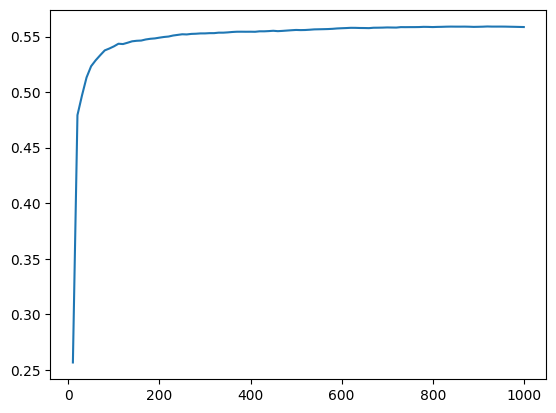

In [67]:
oob = []
times = []
min_estimators = 10
max_estimators = 1000

rf = RandomForestRegressor(warm_start=True, oob_score=True,
                               max_features=1/3, n_jobs=-1)

for i in range(min_estimators,max_estimators+1, 10):
    rf.set_params(n_estimators=i)
    rf.fit(X_train,y_train)
    oob.append(rf.oob_score_)

x_axis = range(min_estimators,max_estimators+1, 10)

plt.plot(x_axis, oob)
plt.show()

200 drzew

In [68]:
rf = RandomForestRegressor(n_estimators=200, n_jobs=-1)

param_grid = {'max_depth': [2,3,4,5,6,7,8,None], 
              'min_samples_leaf': range(5,31), 'max_features':range(2,26)
              }
rf_rscv = RandomizedSearchCV(rf, param_grid, n_iter=100, cv=5, n_jobs=-1)
rf_rscv.fit(X_train, y_train)

,estimator,"RandomForestR...00, n_jobs=-1)"
,param_distributions,"{'max_depth': [2, 3, ...], 'max_features': range(2, 26), 'min_samples_leaf': range(5, 31)}"
,n_iter,100
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [69]:
rf_rscv.best_params_

{'min_samples_leaf': 9, 'max_features': 8, 'max_depth': 8}

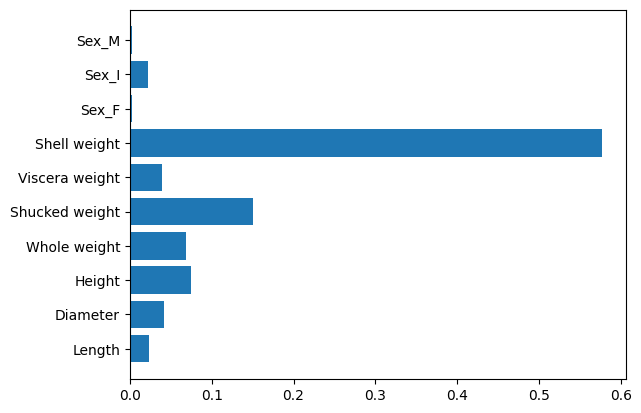

In [74]:
rf = RandomForestRegressor(n_estimators = 200, max_features=8, min_samples_leaf=9, n_jobs=-1, max_depth=8)
rf.fit(X_train,y_train)
feature_importances = rf.feature_importances_
plt.barh(X_train.columns, feature_importances)
plt.show()

In [71]:
y_pred_best = rf_rscv.predict(df_test)

In [72]:
wynik_df = pd.DataFrame({'Rings': y_pred_best})

In [73]:
wynik_df.to_csv('u.csv', index=False)